In [1]:
import os
os.environ['PYTHONHASHSEED'] = str(42)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

### Biblioteki

In [ ]:
from src.data.create_dataset import create_final_dataset
import pandas as pd
import torch

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from src.data.set_seed import set_seed
set_seed(42)

from src.data.data_loader import train_test_split_data, create_dataloader
from src.models.classifier_emb import BinaryClassifierEmbeddings
from src.models.train_model import evaluate_model
from src.visualization.visualize import plot_confusion_matrix

from src.features.clean_column_names import clean_column_names
from src.data.create_ohe_dataset import create_ohe_dataset
from src.data.create_embedding_dataset import create_embeddings_dataset, get_categorical_and_numerical_columns, get_embedding_sizes
from src.models.grid_search import randomized_search_embeddings, full_grid_search_embeddings, random_search_xgb
import json

/home/psik/GITHUB/IUM/IUM-long-stay-insights/src/data/utils.py:13: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


### Device

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Załadowanie danych

In [4]:
final_df = create_final_dataset()
final_df.head()

,id,host_is_superhost,host_verifications,host_acceptance_rate,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,total_english_reviews,count_negative_english,count_positive_english,amenities,standardized_amenities,num_of_amenities,num_of_other_amenities,has_wifi,has_air_conditioning,num_of_top_10_common_amenities
0,27262,t,"['email', 'phone']",100.0,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire rental unit,Entire home/apt,2,...,17.0,0.0,17.0,"[""Heating - split type ductless system"", ""Dish...","['OTHER', 'OTHER', 'OTHER', 'OTHER', 'Refriger...",37,25,True,False,9
1,809874,f,"['email', 'phone']",96.0,ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,37.96215,23.72179,Entire rental unit,Entire home/apt,4,...,82.0,0.0,82.0,"[""Host greets you"", ""Dishes and silverware"", ""...","['OTHER', 'OTHER', 'Washer', 'TV', 'OTHER', 'R...",21,12,True,True,7
2,866381,t,"['email', 'phone', 'work_email']",97.0,ΝΕΟΣ ΚΟΣΜΟΣ,37.95523,23.72443,Entire condo,Entire home/apt,3,...,31.0,0.0,31.0,"[""Coffee"", ""Dishes and silverware"", ""Washer"", ...","['Coffee maker', 'OTHER', 'Washer', 'Condition...",49,29,True,True,12
3,886724,f,['email'],0.0,ΚΥΨΕΛΗ,37.99745,23.73973,Entire rental unit,Entire home/apt,2,...,17.0,1.0,16.0,"[""Host greets you"", ""Luggage dropoff allowed"",...","['OTHER', 'OTHER', 'Washer', 'OTHER', 'OTHER',...",20,13,True,True,6
4,896212,t,"['email', 'phone']",100.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98844,23.73845,Entire rental unit,Entire home/apt,2,...,423.0,3.0,420.0,"[""Host greets you"", ""Coffee"", ""Dishes and silv...","['OTHER', 'Coffee maker', 'OTHER', 'OTHER', 'O...",45,31,True,True,9


# 1. Dostrajanie modelu Embedingowego

In [5]:
set_seed(42)

PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


In [6]:
embeddings_df = create_embeddings_dataset(df=final_df)

emb_categorical_columns, emb_numerical_columns = get_categorical_and_numerical_columns(embeddings_df)

print("Categorical columns: ", emb_categorical_columns)
print("Numerical columns: ", emb_numerical_columns)

embedding_sizes = get_embedding_sizes(embeddings_df, emb_categorical_columns)
print("Embedding sizes: ", embedding_sizes)

if isinstance(emb_categorical_columns, pd.Index):
    print("emb_categorical_columns is a pandas Index. Converting to list.")
    emb_categorical_columns = emb_categorical_columns.tolist()

Categorical columns:  ['host_is_superhost', 'host_verifications', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'license', 'instant_bookable']
Numerical columns:  ['host_acceptance_rate', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'total_bookings', 'total_reviews', 'total_english_reviews', 'count_negative_english', 'count_positive_english', 'num_of_amenities', 'num_of_other_amenities', 'num_of_top_10_common_amenities']
Embedding sizes:  [(3, 2), (8, 4), (171, 50), (62, 31), (4, 2), (37, 19), (11752, 50), (2, 1)]


In [7]:
x_cat_train, x_cat_test, x_num_train, x_num_test, y_train, y_test = train_test_split_data(
    df=embeddings_df,
    emb_categorical_columns=emb_categorical_columns,
    test_size=0.2,
    target_column='target'
)

# adding validation set
x_cat_train_final, x_cat_val, x_num_train_final, x_num_val, y_train_final, y_val = train_test_split(
    x_cat_train,
    x_num_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

emb_train_dataloader = create_dataloader(x_cat_train_final, y_train_final, x_num_train_final, batch_size=32)
emb_val_dataloader = create_dataloader(x_cat_val, y_val, x_num_val, batch_size=32)
emb_test_dataloader = create_dataloader(x_cat_test, y_test, x_num_test, batch_size=32)

### Wyniki przed dostrojeniem

Evaluating: 100%|██████████| 181/181 [00:01<00:00, 170.59it/s]


Accuracy: 0.9280
ROC AUC: 0.9769
Average Precision: 0.9291


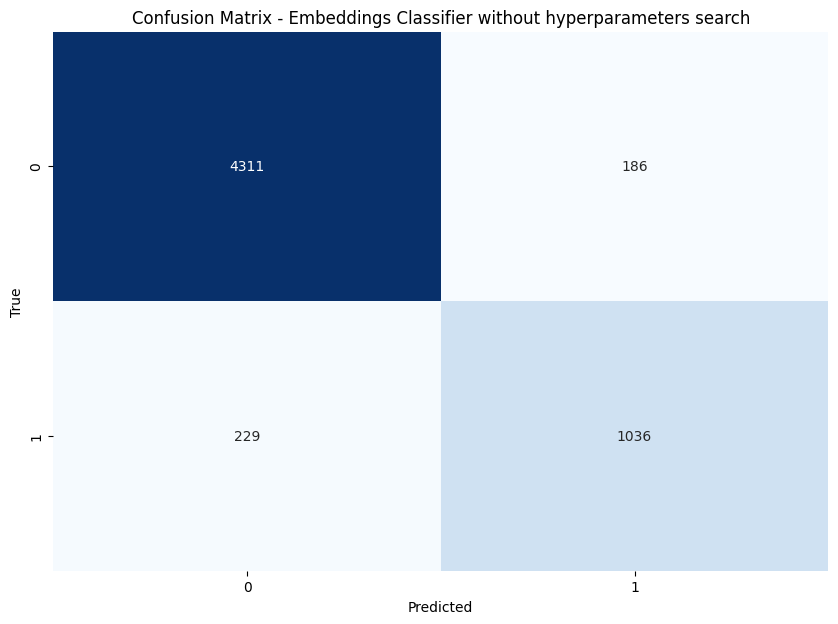

In [8]:
emb_classifier = BinaryClassifierEmbeddings(
    num_numeric=x_num_train_final.shape[1],
    embedding_sizes=embedding_sizes,
    output_size=2
).to(device)

state_dict = torch.load('../models/EMBClassifier.pth', map_location=device)


emb_classifier.load_state_dict(state_dict)

emb_classifier.eval()

y_pred, y_true = evaluate_model(emb_classifier, emb_test_dataloader, device)
y_pred = np.argmax(y_pred, axis=1)
plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix - Embeddings Classifier without hyperparameters search')


### Dostrajanie

In [9]:
set_seed(42)

PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


In [10]:
param_distributions = {
    'lr': np.logspace(-5, -3, 100),
    'batch_size': [32, 64, 128],
    'optimizer': ['adam', 'sgd'],
    'dropout': np.linspace(0.0, 0.5, 6),
    'hidden_sizes': [[64, 32], [128, 64], [256, 128], [256, 128, 64]],
}


results_df = randomized_search_embeddings(
    param_distributions=param_distributions,
    n_iter=10,
    x_cat_train=x_cat_train_final, x_num_train=x_num_train_final, y_train=y_train_final,
    x_cat_val=x_cat_val, x_num_val=x_num_val, y_val=y_val,
    embedding_sizes=embedding_sizes, num_numeric=x_num_train_final.shape[1],
    device=device,
    num_epochs=15
)


# sort by the best validation accuracy, precision and roc_auc
results_df = results_df.sort_values(by=['val_acc', 'avg_precision', 'roc_auc'], ascending=False)



=== Trial 1/10 — Testing params: {'optimizer': 'adam', 'lr': np.float64(5.0941380148163855e-05), 'hidden_sizes': [64, 32], 'dropout': np.float64(0.30000000000000004), 'batch_size': 64}


Epoch [1/15] | Train Loss: 1.1984 | Val Loss: 0.5160 | Val Acc: 0.7798


Epoch [2/15] | Train Loss: 0.6394 | Val Loss: 0.4114 | Val Acc: 0.8002


Epoch [3/15] | Train Loss: 0.5303 | Val Loss: 0.3833 | Val Acc: 0.8262


Epoch [4/15] | Train Loss: 0.4752 | Val Loss: 0.3684 | Val Acc: 0.8371


...

Epoch [13/15] | Train Loss: 0.1501 | Val Loss: 0.1717 | Val Acc: 0.9219


Epoch [14/15] | Train Loss: 0.1479 | Val Loss: 0.1626 | Val Acc: 0.9234


Epoch [15/15] | Train Loss: 0.1435 | Val Loss: 0.1600 | Val Acc: 0.9280
Training complete!


Evaluating: 100%|██████████| 145/145 [00:00<00:00, 186.04it/s]


Accuracy: 0.9280
ROC AUC: 0.9765
Average Precision: 0.9299


In [11]:
results_df.head(10)

,lr,batch_size,optimizer,dropout,hidden_sizes,val_acc,roc_auc,avg_precision
9,0.000046,32,adam,0.0,"(256, 128)",0.927967,0.976496,0.929882
5,0.000453,128,adam,0.2,"(256, 128, 64)",0.921458,0.976049,0.925299
7,0.000226,64,adam,0.1,"(64, 32)",0.921024,0.974495,0.920509
2,0.000830,64,adam,0.0,"(256, 128)",0.912779,0.965999,0.892688
1,0.000040,32,adam,0.1,"(64, 32)",0.911695,0.967164,0.899990
0,0.000051,64,adam,0.3,"(64, 32)",0.882187,0.946166,0.821110
6,0.000071,128,adam,0.2,"(64, 32)",0.878282,0.943628,0.804960
4,0.000830,64,sgd,0.0,"(128, 64)",0.859622,0.931616,0.765998
3,0.000015,128,adam,0.4,"(256, 128, 64)",0.820785,0.861814,0.556116
8,0.000044,64,sgd,0.1,"(256, 128, 64)",0.780430,0.692588,0.324288


## Wnioski z Randomized Search dla modelu embeddingowego

Na podstawie pierwszych dziesięciu prób, dwa topowe zestawy hiperparametrów wyróżniły się:

1. **lr = 4.6e-05**, **batch_size = 32**, **optimizer = adam**, **dropout = 0.0**, **hidden_sizes = (256, 128)**  
   - val_acc: 0.92797  
   - ROC AUC: 0.97650  
   - Average Precision: 0.92988  

2. **lr = 4.5e-04**, **batch_size = 128**, **optimizer = adam**, **dropout = 0.2**, **hidden_sizes = (256, 128, 64)**  
   - val_acc: 0.92146  
   - ROC AUC: 0.97605  
   - Average Precision: 0.92530  

Oba zestawy osiągnęły metryki **bardzo zbliżone** do tych uzyskanych bez dodatkowej optymalizacji hiperparametrów.  
Warto przyjrzeć się im bliżej poprzez:

- Dokładniejsze przeszukiwanie lokalne wokół tych wartości (np. zmniejszone kroki w lr, dodatkowe warianty dropout)
- Ewentualne uwzględnienie innych kombinacji liczby warstw lub ich rozmiarów
- Analizę stabilności w dłuższym treningu lub na większej liczbie epok


In [9]:
param_grid = {
    'lr':           [3e-5, 4e-5, 5e-5],
    'batch_size':   [32, 64],
    'optimizer':    ['adam'],
    'dropout':      [0.1, 0.2],
    'hidden_sizes': [[256,128], [256,128,64]],
}

results_df = full_grid_search_embeddings(
    param_grid,
    x_cat_train_final, x_num_train_final, y_train_final,
    x_cat_val, x_num_val, y_val,
    embedding_sizes,
    num_numeric=x_num_train_final.shape[1],
    device=device,
    num_epochs=20
)


# sort by the best validation accuracy, precision and roc_auc
results_df = results_df.sort_values(by=['val_acc', 'avg_precision', 'roc_auc'], ascending=False)


=== Grid 1/24 — Testing params: {'batch_size': 32, 'dropout': 0.1, 'hidden_sizes': [256, 128], 'lr': 3e-05, 'optimizer': 'adam'}


Train Epoch 1:   0%|          | 0/577 [00:00<?, ?it/s]

Epoch [1/20] | Train Loss: 0.4696 | Val Loss: 0.3492 | Val Acc: 0.8440


Epoch [2/20] | Train Loss: 0.3673 | Val Loss: 0.3114 | Val Acc: 0.8620


Epoch [3/20] | Train Loss: 0.3219 | Val Loss: 0.2775 | Val Acc: 0.8653


...

Epoch [18/20] | Train Loss: 0.1929 | Val Loss: 0.1833 | Val Acc: 0.9176


Epoch [19/20] | Train Loss: 0.1883 | Val Loss: 0.1698 | Val Acc: 0.9212


Epoch [20/20] | Train Loss: 0.1852 | Val Loss: 0.1819 | Val Acc: 0.9219
Training complete!


Evaluating: 100%|██████████| 73/73 [00:00<00:00, 107.40it/s]

Accuracy: 0.9219
ROC AUC: 0.9732
Average Precision: 0.9204


In [10]:
results_df.head(10)

,lr,batch_size,optimizer,dropout,hidden_sizes,val_acc,roc_auc,avg_precision
2,0.00005,32,adam,0.1,"(256, 128)",0.925363,0.974440,0.923764
1,0.00004,32,adam,0.1,"(256, 128)",0.925146,0.973483,0.921562
5,0.00005,32,adam,0.1,"(256, 128, 64)",0.924713,0.975234,0.924922
17,0.00005,64,adam,0.1,"(256, 128, 64)",0.924713,0.974673,0.924203
11,0.00005,32,adam,0.2,"(256, 128, 64)",0.924062,0.974011,0.922816
8,0.00005,32,adam,0.2,"(256, 128)",0.923411,0.973317,0.920430
14,0.00005,64,adam,0.1,"(256, 128)",0.923194,0.972739,0.918688
4,0.00004,32,adam,0.1,"(256, 128, 64)",0.922760,0.973366,0.919901
16,0.00004,64,adam,0.1,"(256, 128, 64)",0.922109,0.973016,0.919234
23,0.00005,64,adam,0.2,"(256, 128, 64)",0.921892,0.973164,0.920389


- Po dokładniejszym przeszukaniu hiperparametrów **nie udało się osiągnąć znaczącej poprawy** jakości względem bazowego modelu.  
- Oznacza to, że dotychczasowe ustawienia (zarówno dla XGBoosta, jak i dla modelu z embeddingami) były już bliskie optimum w badanym zakresie parametrów.  
- Warto rozważyć alternatywne podejścia, np.:
  - dalsze eksperymenty z feature engineering (nowe cechy, interakcje),
  - inne architektury 


# 2. Dostrajanie XGBoost'a

In [5]:
DROP_COLUMNS = ['id', 'mean_embedding', 'listing_id_x', 'listing_id_y', 'amenities', 'standardized_amenities', 'neighbourhood_cleansed', 'license']
POST_COLUMNS = ['availability_eoy', 'number_of_reviews_ly']

xgboost_df = create_ohe_dataset(
    df=final_df,
    drop_cols=DROP_COLUMNS,
    drop_post_ohe=POST_COLUMNS,
    target_col='target',
    fillna_value=0
)

xgboost_df = clean_column_names(xgboost_df)

xgboost_df.head()

,host_acceptance_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,review_scores_accuracy,...,bathrooms_text_7 shared baths,bathrooms_text_8 baths,bathrooms_text_8 shared baths,bathrooms_text_8.5 baths,bathrooms_text_9 baths,bathrooms_text_Half-bath,bathrooms_text_Private half-bath,bathrooms_text_Shared half-bath,instant_bookable_f,instant_bookable_t
0,100.0,37.98924,23.76500,2,1.0,1.0,1.0,131.0,4.86,4.89,...,False,False,False,False,False,False,False,False,False,True
1,96.0,37.96215,23.72179,4,1.0,1.0,2.0,108.0,4.96,4.97,...,False,False,False,False,False,False,False,False,True,False
2,97.0,37.95523,23.72443,3,1.0,1.0,1.0,85.0,4.95,4.98,...,False,False,False,False,False,False,False,False,True,False
3,0.0,37.99745,23.73973,2,1.0,1.0,1.0,56.0,4.61,4.88,...,False,False,False,False,False,False,False,False,True,False
4,100.0,37.98844,23.73845,2,1.0,1.0,1.0,63.0,4.95,4.94,...,False,False,False,False,False,False,False,False,False,True


In [6]:
set_seed(42)

PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


In [7]:
xgboost_df = create_ohe_dataset(
    df=final_df,
    drop_cols=DROP_COLUMNS,
    drop_post_ohe=POST_COLUMNS,
    target_col='target',
    fillna_value=0
)

xgboost_df = clean_column_names(xgboost_df)

xgboost_df.head()

x_train, x_test, y_train, y_test = train_test_split_data(
    xgboost_df,
    test_size=0.2,
    target_column='target'
)

In [ ]:
from scipy.stats import randint, uniform, loguniform

param_distributions = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 11),
    'learning_rate':    loguniform(0.005, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'gamma':            uniform(0, 0.3),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha':        uniform(0, 0.2),
    'reg_lambda':       uniform(0, 0.2),
}


search_results = random_search_xgb(
    x_train=x_train, y_train=y_train,
    x_test=x_test, y_test=y_test,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    random_state=42,
    scoring='roc_auc',
)


PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=200, reg_alpha=0.1, reg_lambda=0.2, subsample=1.0; total time=   2.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=200, reg_alpha=0.1, reg_lambda=0.2, subsample=1.0; total time=   2.8s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=200, reg_alpha=0.1, reg_lambda=0.2, subsample=1.0; total time=   4.0s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=6, n_estimators=200, reg_alpha=0.2, reg_lambda=0.1, subsample=1.0; total time=   4.2s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_depth=6, n_estimators=200, reg_alpha=0.2, reg_lambda=0.1, subsample=1

In [13]:
search_results

(RandomizedSearchCV(cv=3,
                    estimator=XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_cons...
                                            n_estimators=None, n_jobs=None,
     

In [19]:
best_params = search_results[1]
print("Best parameters found: ", best_params)

save_path = '../models/XGBClassifier_hyperparameters_search.pth'
json.dump(best_params, open(save_path, 'w'), indent=4)

Best parameters found:  {'best_params': {'subsample': 0.6, 'reg_lambda': 0.2, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}, 'best_cv_score': np.float64(0.9963188989280797), 'test_accuracy': 0.9765706351961124, 'test_roc_auc': np.float64(0.9965972923538837), 'test_avg_precision': np.float64(0.9879742903252775)}
